## Preprocessing

In [669]:
import pandas as pd
import glob
from utils import *

In [670]:
dfs = []
for file in glob.glob(f"../results/experiment*solvers*.csv"):
    dfs.append(pd.read_csv(file))
df = pd.concat(dfs, ignore_index=True)
df = process_experiments_df(df)
df.head()

,datetime,test case,p,mesh family,fine m,solvers m,coarse m,solver,random rhs,solution warmup steps,...,residual norm,setup metadata,solve times,matrix and DOF map copy times,matrix permute times,solver setup times,rhs copy and permute times,solution permute and copy times,exception,dim
0,2026-02-03T08:25:22.926048+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=T...",False,0,...,2.461959e-10,None,"[1818.7965087890625, 42.148929595947266, 41.26...",[8.393664360046387],[0.026367999613285065],[539.3482666015625],[0.7207679748535156],[1.954975962638855],NaN,2D
1,2026-02-03T08:25:40.282708+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESIVE_L1, torch.float32), bsr_matm...",False,0,...,3.166015e-10,None,"[52.22780990600586, 50.53260803222656, 50.4231...",[34.7243537902832],[0.013567999936640263],[136.02227783203125],[3.2070400714874268],[0.6393280029296875],NaN,2D
2,2026-02-03T08:25:41.178442+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESSIVE_L1_TRUNC, torch.float32), b...",False,0,...,2.357255e-10,None,"[45.81350326538086, 44.25766372680664, 44.0071...",[8.530303955078125],[0.011648000217974186],[164.90480041503906],[0.4811199903488159],[0.4039359986782074],NaN,2D
3,2026-02-03T08:25:42.199448+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,"CG(AMGX(AGGRESSIVE_CHEB_L1_TRUNC, torch.float3...",False,0,...,1.890703e-10,None,"[51.94255828857422, 51.97564697265625, 51.2618...",[8.527968406677246],[0.023423999547958374],[163.91920471191406],[0.5018560290336609],[0.4713279902935028],NaN,2D
4,2026-02-03T08:25:42.985574+00:00,continuous coefficient 2D,1,"uniform(2D,8)",S8,-,-,CUDSS,False,0,...,2.594297e-13,None,"[4.678783893585205, 2.549760103225708, 2.52313...",[8.45587158203125],[0.012608000077307224],[485.43939208984375],[0.26281601190567017],[0.6216319799423218],NaN,2D


In [671]:
df["best solve time"] = df["solve times"].apply(
    lambda times: min(times) if times else None
)
df["best DoF/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"] * 1000,
    axis=1,
)

In [672]:
def nice_solver_name(name):
    if name == "CUDSS":
        return "cuDSS"
    elif "Additive" in name:
        return "Additive Schwarz"
    elif "Hybrid" in name:
        return "Hybrid Schwarz"
    else:  # AmgX
        config, precision = name.split("AMGX(")[1].split(")")[0].split(",")
        config = config.replace("AGGRESIVE", "AGGRESSIVE")  # typo...
        precision = "fp32" if precision.strip() == "torch.float32" else "fp64"
        return f"AmgX ({config}, {precision})"


df["nice solver"] = df["solver"].apply(nice_solver_name)

## Is the data complete?

In [673]:
assert df["solve times"].isna().sum() == (~df["exception"].isna()).sum()

In [674]:
manually_verified_to_fail = pd.read_csv("../results/manually_verified_to_fail.csv")
manually_verified_to_fail

,test case,p,fine m,solver,exception
0,continuous coefficient 2D,4,S10,"CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=T...",Thrust failure: parallel_for: failed to synchr...
1,continuous coefficient 3D,1,S7,CUDSS,RuntimeError: CUDA error: an illegal memory ac...


In [675]:
problems = df[["test case", "p", "fine m"]].drop_duplicates().reset_index(drop=True)
solvers = df["solver"].unique()

complete = True
for test_case, p, fine_m in problems.itertuples(index=False):
    for solver in solvers:
        df_subset = df[
            (df["test case"] == test_case)
            & (df["p"] == p)
            & (df["fine m"] == fine_m)
            & (df["solver"] == solver)
        ]
        manually_subset = manually_verified_to_fail[
            (manually_verified_to_fail["test case"] == test_case)
            & (manually_verified_to_fail["p"] == p)
            & (manually_verified_to_fail["fine m"] == fine_m)
            & (manually_verified_to_fail["solver"] == solver)
        ]
        if df_subset.empty and manually_subset.empty:
            complete = False
            print(f"No data for {test_case}, p={p}, fine m={fine_m}, solver={solver}")

if complete:
    print(
        "All combinations of test case, p, fine m, and solver are covered in the data!"
    )

No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(AGGRESIVE_L1, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(AGGRESSIVE_L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=1, fine m=S12, solver=CG(AMGX(AGGRESSIVE_CHEB_L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(AGGRESIVE_L1, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(AGGRESSIVE_L1_TRUNC, None), bsr_matmul=True)
No data for continuous coefficient 2D, p=4, fine m=S10, solver=CG(AMGX(AGGRESSIVE_CHEB_L1_TRUNC, None), bsr_matmul=True)


## Throughput vs polynomial degree

In [676]:
NUM_LARGEST_TO_CONSIDER_IN_TPUT = 2


def get_m(mesh):
    return int(mesh[1:])


large_problems = pd.DataFrame(
    [
        problem
        for _, problem in problems.iterrows()
        if get_m(problem["fine m"]) + NUM_LARGEST_TO_CONSIDER_IN_TPUT
        > problems[
            (problems["test case"] == problem["test case"])
            & (problems["p"] == problem["p"])
        ]["fine m"]
        .map(get_m)
        .max()
    ]
)

df_large = df.merge(large_problems, on=["test case", "p", "fine m"], how="inner")

In [688]:
tputs = df_large.pivot_table(
    values="best DoF/s",
    index=["test case", "p", "fine m"],
    columns=["nice solver"],
    aggfunc="max",
)
tputs

nice solver                         Additive Schwarz  \
test case                 p fine m                     
continuous coefficient 2D 1 S11         3.762286e+07   
                            S12         4.026913e+07   
                          2 S10         1.790441e+07   
                            S11         1.933144e+07   
                          3 S10         1.207093e+07   
                            S9          1.027682e+07   
                          4 S10         8.525925e+06   
                            S9          7.743615e+06   
                          5 S8          5.368818e+06   
                            S9          6.362715e+06   
continuous coefficient 3D 1 S6          2.303760e+07   
                            S7          2.685677e+07   
                          2 S5          7.647964e+06   
                            S6          1.047797e+07   
                          3 S4          2.838697e+06   
                            S5          4.969676e+06   
                          4 S4          2.161981e+06   
                            S5          2.787899e+06   
                          5 S3          9.950149e+05   
                            S4          1.393510e+06   

nice solver                         AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp32)  \
test case                 p fine m                                          
continuous coefficient 2D 1 S11                              3.078130e+07   
                            S12                              3.093139e+07   
                          2 S10                                       NaN   
                            S11                                       NaN   
                          3 S10                                       NaN   
                            S9                                        NaN   
                          4 S10                                       NaN   
                            S9                                        NaN   
                          5 S8                                        NaN   
                            S9                                        NaN   
continuous coefficient 3D 1 S6                               1.763037e+07   
                            S7                               1.945146e+07   
                          2 S5                               6.027738e+06   
                            S6                               7.067195e+06   
                          3 S4                               6.268366e+05   
                            S5                               4.132536e+05   
                          4 S4                               4.416016e+05   
                            S5                               2.720937e+05   
                          5 S3                               2.689881e+05   
                            S4                                        NaN   

nice solver                         AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp64)  \
test case                 p fine m                                          
continuous coefficient 2D 1 S11                              1.961678e+07   
                            S12                                       NaN   
                          2 S10                                       NaN   
                            S11                                       NaN   
                          3 S10                                       NaN   
                            S9                                        NaN   
                          4 S10                                       NaN   
                            S9                                        NaN   
                          5 S8                                        NaN   
                            S9                                        NaN   
continuous coefficient 3D 1 S6                               1.193664e+07   
                            S7                               1.253481e+

In [678]:
style_map = {
    "Hybrid Schwarz": ("tab:green", "solid"),
    "Additive Schwarz": ("tab:orange", "solid"),
    "AmgX (AGGRESSIVE_L1, fp32)": ("tab:pink", "solid"),
    "AmgX (AGGRESSIVE_L1, fp64)": ("tab:pink", "dashed"),
    "AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp32)": ("tab:gray", "solid"),
    "AmgX (AGGRESSIVE_CHEB_L1_TRUNC, fp64)": ("tab:gray", "dashed"),
    "AmgX (AGGRESSIVE_L1_TRUNC, fp32)": ("tab:olive", "solid"),
    "AmgX (AGGRESSIVE_L1_TRUNC, fp64)": ("tab:olive", "dashed"),
    "AmgX (L1_TRUNC, fp32)": ("tab:cyan", "solid"),
    "AmgX (L1_TRUNC, fp64)": ("tab:cyan", "dashed"),
}

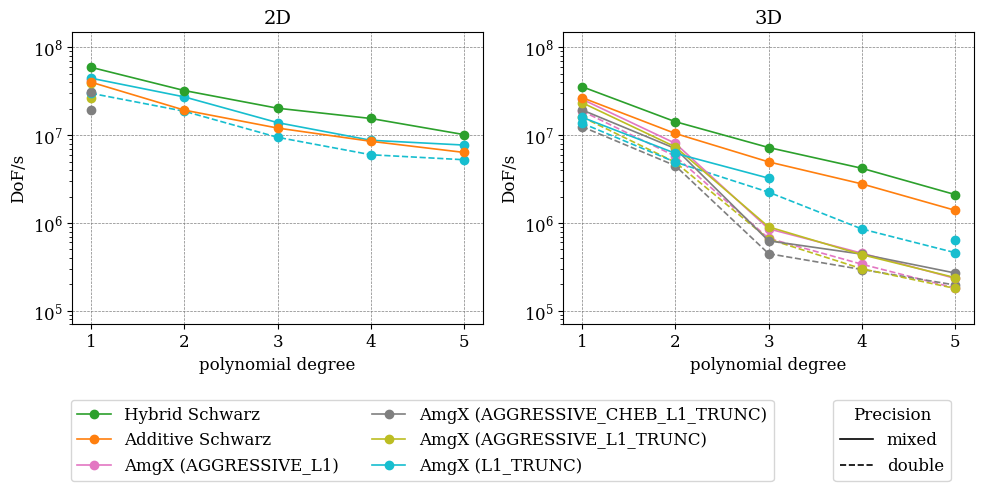

In [679]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, len(tputs.index.levels[0]), figsize=(10, 4), layout="tight")
for i, test_case in enumerate(tputs.index.levels[0]):
    ax = axes[i]
    data = tputs.loc[test_case]
    for solver, (color, line_style) in style_map.items():
        if data[solver].isna().all():
            continue
        label = solver.split(",")[0] + ")" if "AmgX" in solver else solver
        zorder = 5 if "AmgX" in solver else 10
        if line_style == "solid":
            zorder += 1
        ax.plot(
            data.index,
            data[solver],
            marker="o",
            linestyle=line_style,
            color=color,
            label=label if i == 0 and line_style == "solid" else None,
            zorder=zorder,
            linewidth=1.2,
        )
    ax.set_title(test_case.split()[-1])
    ax.set_xlabel("polynomial degree")
    ax.set_ylabel("DoF/s")
    ax.set_yscale("log")
    ax.set_ylim(7e4, 1.5e8)
    ax.grid(which="major", linestyle="--", linewidth=0.5, color="grey")
fig.legend(bbox_to_anchor=(0.43, -0.0), loc="upper center", ncol=2)

fig.legend(
    [
        Line2D([0], [0], color="black", linestyle="solid", linewidth=1.2),
        Line2D([0], [0], color="black", linestyle="dashed", linewidth=1.2),
    ],
    ["mixed", "double"],
    bbox_to_anchor=(0.9, -0.0),
    loc="upper center",
    ncol=1,
    title="Precision",
)

fig.savefig("../docs/images/throughput_vs_amgx.svg", bbox_inches="tight")

## Largest managable problems

In [680]:
def matrix_size(row):
    nnz = row["matrix nnz"]
    n = row["DoFs"]
    return nnz * (8 + 4) + (n + 1) * 4


df["matrix size (bytes)"] = df.apply(matrix_size, axis=1)
df["short solver"] = df["nice solver"].map(
    lambda name: "AmgX" if "AmgX" in name else name
)

df[df["exception"].isna()].pivot_table(
    index=["test case", "p"],
    columns="short solver",
    values="matrix nnz",
    aggfunc="max",
).map(lambda x: f"{x:,}" if pd.notna(x) else "N/A")

short solver                Additive Schwarz           AmgX Hybrid Schwarz  \
test case                 p                                                  
continuous coefficient 2D 1    1,207,812,096  1,207,812,096  1,207,812,096   
                          2    1,207,664,640  1,207,664,640  1,207,664,640   
                          3      838,451,200    838,451,200    838,451,200   
                          4    1,886,515,200    471,398,400  1,886,515,200   
                          5      923,940,864    923,940,864    923,940,864   
continuous coefficient 3D 1    1,003,487,232  1,003,487,232  1,003,487,232   
                          2      781,516,800    781,516,800    781,516,800   
                          3      388,300,800    388,300,800    388,300,800   
                          4    1,189,171,200  1,189,171,200  1,189,171,200   
                          5      375,717,888    375,717,888    375,717,888   

short solver                       cuDSS  
test case                 p               
continuous coefficient 2D 1  301,916,160  
                          2  301,842,432  
                          3  838,451,200  
                          4  471,398,400  
                          5  923,940,864  
continuous coefficient 3D 1   15,532,032  
                          2   97,075,200  
                          3   47,923,200  
                          4  146,764,800  
                          5  375,717,888

In [681]:
problems = (
    df[["test case", "p", "mesh family", "fine m"]]
    .drop_duplicates()
    .sort_values(by=["test case", "p", "mesh family", "fine m"])
    .reset_index(drop=True)
)

problems = problems[~problems["mesh family"].str.contains("unstructured")]

In [682]:
def get_m(mesh):
    return int(mesh[1:])


largest_problems = pd.DataFrame(
    [
        problem
        for _, problem in problems.iterrows()
        if problems[
            (problems["test case"] == problem["test case"])
            & (problems["p"] == problem["p"])
        ]["fine m"]
        .map(get_m)
        .max()
        == get_m(problem["fine m"])
    ]
)

largest_problems

,test case,p,mesh family,fine m
2,continuous coefficient 2D,1,"uniform(2D,12)",S12
6,continuous coefficient 2D,2,"uniform(2D,11)",S11
11,continuous coefficient 2D,3,"uniform(2D,10)",S10
16,continuous coefficient 2D,4,"uniform(2D,10)",S10
26,continuous coefficient 2D,5,"uniform(2D,9)",S9
31,continuous coefficient 3D,1,"uniform(3D,7)",S7
36,continuous coefficient 3D,2,"uniform(3D,6)",S6
41,continuous coefficient 3D,3,"uniform(3D,5)",S5
46,continuous coefficient 3D,4,"uniform(3D,5)",S5
50,continuous coefficient 3D,5,"uniform(3D,4)",S4


## Speedup table

In [683]:
def find_best_variants(df: pd.DataFrame) -> pd.DataFrame:
    df = df[df.solver.str.contains("CG")].copy()

    summary = df.pivot_table(
        index=["solver"],
        columns=["coarse m", "solvers m"],
        values="best solve time",
        aggfunc="min",
    )
    summary["best"] = summary.min(axis=1)

    best_amgx_key = summary["best"][summary.index.str.contains("AMGX")].idxmin()
    best_amgx_variant = best_amgx_key[8:].split(",")[0]
    best_amgx_time = summary["best"][best_amgx_key]

    best_additive_key = summary["best"][
        summary.index.str.contains("AdditiveSchwarz")
    ].idxmin()
    best_additive_time = summary["best"][best_additive_key]
    best_additive_by_meshes = summary[
        summary.index.str.contains("AdditiveSchwarz")
    ].min()
    best_additive_meshing = best_additive_by_meshes.idxmin()

    best_hybrid_key = summary["best"][
        summary.index.str.contains("HybridSchwarz")
    ].idxmin()
    best_hybrid_time = summary["best"][best_hybrid_key]
    best_hybrid_by_meshes = summary[summary.index.str.contains("HybridSchwarz")].min()
    best_hybrid_meshing = best_hybrid_by_meshes.idxmin()

    return pd.Series(
        {
            "best_amgx_variant": best_amgx_variant,
            "best_amgx_time": best_amgx_time,
            "best_additive_time": best_additive_time,
            "best_additive_meshing": best_additive_meshing,
            "best_hybrid_time": best_hybrid_time,
            "best_hybrid_meshing": best_hybrid_meshing,
        }
    )

In [684]:
def get_dofs(d, fine_m, p):
    element_dofs = {
        # (d, p)
        (2, 1): 3,
        (2, 2): 6,
        (2, 3): 10,
        (2, 4): 15,
        (2, 5): 21,
        (3, 1): 4,
        (3, 2): 10,
        (3, 3): 20,
        (3, 4): 35,
        (3, 5): 56,
    }
    return 2 ** (d * fine_m) * (2 if d == 2 else 6) * element_dofs[(d, p)]

In [685]:
def get_problem_summary(problem):
    print(problem)
    test_case = problem["test case"]
    p = problem["p"]
    mesh_family = problem["mesh family"]
    fine_m = problem["fine m"]

    data = df[
        (df["test case"] == test_case)
        & (df["p"] == p)
        & (df["fine m"] == fine_m)
        & (df["mesh family"] == mesh_family)
    ]
    if data.empty:
        return pd.Series()

    summary = find_best_variants(data)
    d = int(test_case[-2])
    summary["d"] = d
    summary["mesh family"] = mesh_family
    summary["m"] = fine_m
    summary["p"] = p
    summary["DoFs"] = get_dofs(d, int(fine_m[1:]), p) if fine_m != "F" else None

    return summary

In [686]:
get_problem_summary(largest_problems.iloc[0])

test case      continuous coefficient 2D
p                                      1
mesh family               uniform(2D,12)
fine m                               S12
Name: 2, dtype: object


best_amgx_variant              L1_TRUNC
best_amgx_time              2252.932373
best_additive_time          2499.763428
best_additive_meshing        (C10, S11)
best_hybrid_time            1824.602905
best_hybrid_meshing          (C11, C12)
d                                     2
mesh family              uniform(2D,12)
m                                   S12
p                                     1
DoFs                          100663296
dtype: object

In [687]:
speedup_table = pd.DataFrame(
    get_problem_summary(problem) for _, problem in largest_problems.iterrows()
)
speedup_table

test case      continuous coefficient 2D
p                                      1
mesh family               uniform(2D,12)
fine m                               S12
Name: 2, dtype: object
test case      continuous coefficient 2D
p                                      2
mesh family               uniform(2D,11)
fine m                               S11
Name: 6, dtype: object
test case      continuous coefficient 2D
p                                      3
mesh family               uniform(2D,10)
fine m                               S10
Name: 11, dtype: object
test case      continuous coefficient 2D
p                                      4
mesh family               uniform(2D,10)
fine m                               S10
Name: 16, dtype: object


ValueError: attempt to get argmin of an empty sequence

In [ ]:
# assert (speedup_table["best_asm_precision"] == "fp32+fp16").all()
# assert (speedup_table["best_parallel_precision"] == "fp32+fp16").all()
# assert (speedup_table["best_classical_precision"] == "fp32+fp16").all()

In [ ]:
tab = pd.DataFrame()
tab[["$d$", "$p$"]] = speedup_table[["d", "p"]]
tab["$\\mathcal{T}_h$"] = speedup_table["m"].apply(lambda m: f"${format_mesh(m)}$")
tab["DoFs"] = speedup_table["DoFs"].apply(lambda n: f"{n / 1_000_000:.1f}\\,{{M}}")

amgx_best = "best AmgX configuration found"
additive_best = "best AdditiveSchwarz variant"
hybrid_best = "best HybridSchwarz variant"

tab[(amgx_best, "name")] = speedup_table["best_amgx_variant"].map(
    lambda v: f"\\verb|{v.replace('AGGRESIVE', 'AGGRESSIVE')}|"
)
tab[(amgx_best, "time")] = speedup_table["best_amgx_time"] / 1000
tab[(additive_best, "$\\mathcal{T}_\\mathcal{H}$")] = speedup_table[
    "best_additive_meshing"
].map(lambda m: f"${format_mesh(m[0])}$")
tab[(additive_best, "$\\mathcal{T}_H$")] = speedup_table["best_additive_meshing"].map(
    lambda m: f"${format_mesh(m[1])}$"
)
tab[(additive_best, "time")] = speedup_table["best_additive_time"] / 1000
tab[(additive_best, "speedup")] = (
    tab[(amgx_best, "time")] / tab[(additive_best, "time")]
)

tab[(hybrid_best, "$\\mathcal{T}_\\mathcal{H}$")] = speedup_table[
    "best_hybrid_meshing"
].map(lambda m: f"${format_mesh(m[0])}$")
tab[(hybrid_best, "$\\mathcal{T}_H$")] = speedup_table["best_hybrid_meshing"].map(
    lambda m: f"${format_mesh(m[1])}$"
)
tab[(hybrid_best, "time")] = speedup_table["best_hybrid_time"] / 1000
tab[(hybrid_best, "speedup")] = tab[(amgx_best, "time")] / tab[(hybrid_best, "time")]

tab.set_index(["$d$", "$p$", "$\\mathcal{T}_h$", "DoFs"], inplace=True)


def time_latex(t: float):
    return f"{t:.6f}\\, \\si{{\\second}}"


def speedup_latex(s: float):
    return f"{s:.6f} \\,\\(\\times\\)"


tab[(amgx_best, "time")] = tab[(amgx_best, "time")].apply(time_latex)
tab[(additive_best, "time")] = tab[(additive_best, "time")].apply(time_latex)
tab[(additive_best, "speedup")] = tab[(additive_best, "speedup")].apply(speedup_latex)
tab[(hybrid_best, "time")] = tab[(hybrid_best, "time")].apply(time_latex)
tab[(hybrid_best, "speedup")] = tab[(hybrid_best, "speedup")].apply(speedup_latex)

tab.columns = pd.MultiIndex.from_tuples(tab.columns)
tab.rename(columns=lambda c: f"{{{c}}}", inplace=True)
tab

{best AmgX configuration found}  \
                                                               {name}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                         
2   1   $\mathcal{S}_{12}$ 100.7\,{M}                 \verb|L1_TRUNC|   
    3   $\mathcal{S}_{10}$ 21.0\,{M}                  \verb|L1_TRUNC|   
    5   $\mathcal{S}_{9}$  11.0\,{M}                  \verb|L1_TRUNC|   
3   1   $\mathcal{S}_{7}$  50.3\,{M}             \verb|AGGRESSIVE_L1|   
    2   $\mathcal{S}_{6}$  15.7\,{M}             \verb|AGGRESSIVE_L1|   
    3   $\mathcal{S}_{5}$  3.9\,{M}                   \verb|L1_TRUNC|   
    4   $\mathcal{S}_{4}$  0.9\,{M}              \verb|AGGRESSIVE_L1|   

                                                                \
                                                        {time}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                  
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  2.252932\, \si{\second}   
    3   $\mathcal{S}_{10}$ 21.0\,{M}   1.507047\, \si{\second}   
    5   $\mathcal{S}_{9}$  11.0\,{M}   1.425345\, \si{\second}   
3   1   $\mathcal{S}_{7}$  50.3\,{M}   1.952959\, \si{\second}   
    2   $\mathcal{S}_{6}$  15.7\,{M}   1.943804\, \si{\second}   
    3   $\mathcal{S}_{5}$  3.9\,{M}    1.212115\, \si{\second}   
    4   $\mathcal{S}_{4}$  0.9\,{M}    1.899892\, \si{\second}   

                                      {best AdditiveSchwarz variant}  \
                                         {$\mathcal{T}_\mathcal{H}$}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                        
2   1   $\mathcal{S}_{12}$ 100.7\,{M}             $\mathcal{C}_{10}$   
    3   $\mathcal{S}_{10}$ 21.0\,{M}               $\mathcal{S}_{9}$   
    5   $\mathcal{S}_{9}$  11.0\,{M}               $\mathcal{S}_{9}$   
3   1   $\mathcal{S}_{7}$  50.3\,{M}               $\mathcal{C}_{6}$   
    2   $\mathcal{S}_{6}$  15.7\,{M}               $\mathcal{C}_{5}$   
    3   $\mathcal{S}_{5}$  3.9\,{M}                $\mathcal{C}_{5}$   
    4   $\mathcal{S}_{4}$  0.9\,{M}                $\mathcal{C}_{4}$   

                                                           \
                                        {$\mathcal{T}_H$}   
$d$ $p$ $\mathcal{T}_h$    DoFs                             
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  $\mathcal{S}_{11}$   
    3   $\mathcal{S}_{10}$ 21.0\,{M}    $\mathcal{S}_{9}$   
    5   $\mathcal{S}_{9}$  11.0\,{M}    $\mathcal{S}_{9}$   
3   1   $\mathcal{S}_{7}$  50.3\,{M}    $\mathcal{C}_{7}$   
    2   $\mathcal{S}_{6}$  15.7\,{M}    $\mathcal{C}_{6}$   
    3   $\mathcal{S}_{5}$  3.9\,{M}     $\mathcal{C}_{5}$   
    4   $\mathcal{S}_{4}$  0.9\,{M}     $\mathcal{C}_{4}$   

                                                                \
                                                        {time}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                  
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  2.499763\, \si{\second}   
    3   $\mathcal{S}_{10}$ 21.0\,{M}   1.737357\, \si{\second}   
    5   $\mathcal{S}_{9}$  11.0\,{M}   1.730401\, \si{\second}   
3   1   $\mathcal{S}_{7}$  50.3\,{M}   1.874077\, \si{\second}   
    2   $\mathcal{S}_{6}$  15.7\,{M}   1.501115\, \si{\second}   
    3   $\mathcal{S}_{5}$  3.9\,{M}    0.791231\, \si{\second}   
    4   $\mathcal{S}_{4}$  0.9\,{M}    0.397857\, \si{\second}   

                                                              \
                                                   {speedup}   
$d$ $p$ $\mathcal{T}_h$    DoFs                                
2   1   $\mathcal{S}_{12}$ 100.7\,{M}  0.901258 \,\(\times\)   
    3   $\mathcal{S}_{10}$ 21.0\,{M}   0.867437 \,\(\times\)   
    5   $\mathcal{S}_{9}$  11.0\,{M}   0.823708 \,\(\times\)   
3   1   $\mathcal{S}_{7}$  50.3\,{M}   1.042091 \,\(\times\)   
    2   $\mathcal{S}_{6}$  15.7\,{M}   1.294907 \,\(\times\)   
    3   $\mathcal{S}_{5}$  3.9\,{M}    1.531937 \,\(\times\)   
    4   $\mathcal{S}_{4}$  0.9\,{M}    4.775308 \,\(\times\)   

            

In [ ]:
time_col = "S[table-format=1.3\\,s, round-mode=places, round-precision=3]"
speedup_col = "S[table-format=1.3, round-mode=places, round-precision=3]"
dofs_col = "S[table-format=2.1\\,M]"
tab_latex = tab.style.to_latex(
    hrules=True,
    multirow_align="t",
    multicol_align="c",
    column_format=f"rrc{dofs_col}|l{time_col}|cc{time_col}{speedup_col}|cc{time_col}{speedup_col}",
)

In [ ]:
custom_header = r"""
 &  &  &  & \multicolumn{2}{c|}{{best AmgX configuration found}} & \multicolumn{4}{c|}{{best additive variant considered}} & \multicolumn{4}{c}{{best hybrid variant considered}} \\
$d$ & $p$ & $\mathcal{T}_h$ & {DoFs} & {name} & {time} & {$\mathcal{T}_\mathcal{H}$} & {$\mathcal{T}_H$} & {time} & {speedup} & {$\mathcal{T}_\mathcal{H}$} & {$\mathcal{T}_H$} & {time} & {speedup} \\
"""

before_header = tab_latex.split("\\toprule")[0] + "\\toprule\n"
after_header = "\n\\midrule\n" + tab_latex.split("\\midrule")[1]
hacked_latex = before_header + custom_header + after_header
hacked_latex = hacked_latex.replace(
    "\\multirow[t]{3}{*}{3}", "\\midrule\n\\multirow[t]{3}{*}{3}"
)

In [ ]:
with open("../docs/tables/experiment_speedups.tex", "w") as f:
    f.write(hacked_latex)